# Importing Libraries

In [ ]:
import warnings, json, time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
OUT = 'outputs'
RESULTS = {}
os.makedirs(OUT, exist_ok=True)

t0 = time.time()
def log(msg): print(f"[{time.time()-t0:6.1f}s] {msg}", flush=True)

# Loading Dataset

In [ ]:
# Creating a dataframe
df = pd.read_csv('ev_battery_failure_dataset.csv')
TARGET = 'battery_failure'

In [ ]:
print(f"Number of Rows and Columns: {df.shape}")
print('\n')
df.info() # An overview
df.describe() # Statistical Summary

Number of Rows and Columns: (200000, 70)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 70 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   vehicle_id                       200000 non-null  object 
 1   vehicle_brand                    193564 non-null  object 
 2   vehicle_model                    191796 non-null  object 
 3   vehicle_type                     193568 non-null  object 
 4   manufacturing_year               190171 non-null  float64
 5   battery_manufacturer             193812 non-null  object 
 6   battery_chemistry                192786 non-null  object 
 7   battery_capacity_kwh             193097 non-null  float64
 8   drive_type                       192732 non-null  object 
 9   odometer_km                      191334 non-null  float64
 10  vehicle_age_years                192317 non-null  float64
 11  fleet_or_private      

,manufacturing_year,battery_capacity_kwh,odometer_km,vehicle_age_years,cycle_count,battery_health_percent,state_of_charge,depth_of_discharge,state_of_health,cell_voltage_avg,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
count,190171.000000,193097.000000,191334.000000,192317.000000,192348.000000,191018.000000,190364.000000,191687.000000,190435.000000,190602.000000,...,190326.000000,190948.000000,192400.000000,192691.000000,191635.000000,193671.000000,192814.000000,193190.000000,191026.000000,200000.000000
mean,2019.501333,76.236405,102822.193327,6.495245,296.383934,87.381787,54.847079,38.290397,87.297020,3.288515,...,1.331032,2.024745,0.494595,35.179580,29.912538,63.538378,50.989061,40.948318,1859.485986,0.099605
std,2.873497,21.302330,87965.819977,2.878180,282.614453,12.540742,21.450372,12.754524,12.527256,0.246766,...,1.265969,1.579874,0.729369,21.789144,28.011328,13.764340,27.815242,29.848473,1834.356925,0.299473
min,2015.000000,25.000000,500.000000,1.370000,1.000000,21.420000,2.000000,5.000000,21.800000,2.048500,...,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,60.980000,36128.000000,4.000000,95.000000,80.990000,40.070000,29.600000,80.910000,3.106025,...,0.000000,1.000000,0.000000,19.300000,6.900000,53.900000,30.600000,15.500000,891.000000,0.000000
50%,2020.000000,75.350000,78919.000000,6.340000,218.000000,91.120000,54.940000,38.280000,91.050000,3.355800,...,1.000000,2.000000,0.000000,33.200000,22.600000,61.400000,53.500000,38.900000,1245.000000,0.000000
75%,2022.000000,89.990000,146010.750000,9.000000,412.000000,97.430000,69.780000,46.910000,97.330000,3.463900,...,2.000000,3.000000,1.000000,48.500000,45.100000,74.000000,72.800000,63.000000,3085.000000,0.000000
max,2024.000000,149.010000,450000.000000,11.550000,3369.000000,99.800000,100.000000,92.030000,100.000000,3.853000,...,10.000000,13.000000,7.000000,100.000000,100.000000,100.000000,100.000000,100.000000,15474.000000,1.000000


# Exploratory Data Analysis

In [ ]:
eda = {}
eda['shape'] = list(df.shape)
eda['duplicates'] = int(df.duplicated().sum())
eda['target_counts'] = df[TARGET].value_counts().to_dict()
eda['failure_rate'] = float(df[TARGET].mean())
eda['imbalance_ratio'] = float((df[TARGET] == 0).sum() / (df[TARGET] == 1).sum())
miss = (df.isna().mean() * 100).sort_values(ascending=False)
eda['missing_top15'] = miss.head(15).round(2).to_dict()
eda['cols_with_missing'] = int((miss > 0).sum())
log(f"Failure rate {eda['failure_rate']:.4f} | imbalance 1:{eda['imbalance_ratio']:.1f}")

[  12.2s] Failure rate 0.0996 | imbalance 1:9.0


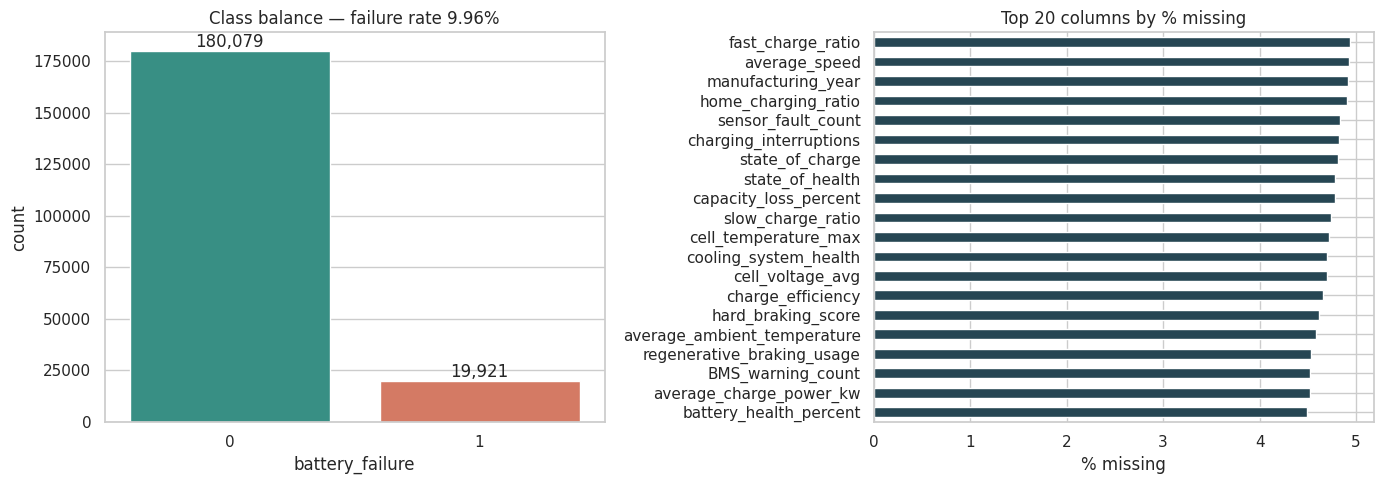

In [ ]:
# target balance and missingness
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Class balance
sns.countplot(x=df[TARGET], ax=ax[0], palette=['#2a9d8f', '#e76f51'])
ax[0].set_title(f'Class balance — failure rate {df[TARGET].mean():.2%}')
ax[0].set_xlabel('battery_failure')
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                   ha='center', va='bottom')

# Plot 2: Missingness
miss.head(20).plot(kind='barh', ax=ax[1], color='#264653')
ax[1].invert_yaxis()
ax[1].set_title('Top 20 columns by % missing')
ax[1].set_xlabel('% missing')

# Save and clear memory
plt.tight_layout()
plt.savefig(f'{OUT}/fig1_target_and_missing.png', dpi=110)
plt.show()

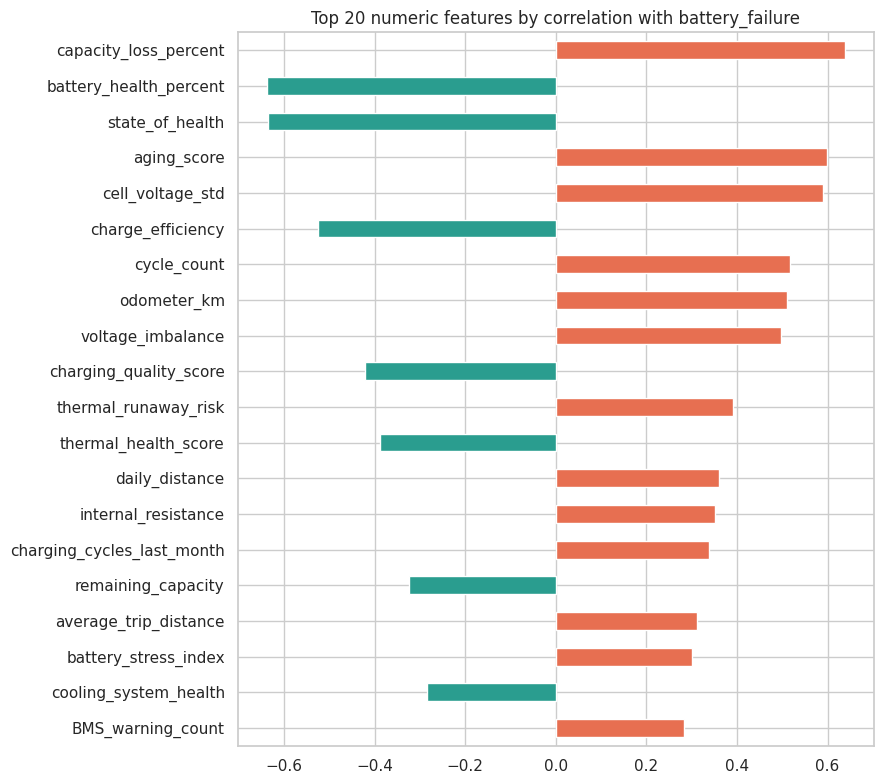

In [ ]:
# correlation of numeric features with target

# Selects all columns with number types (float, int) and removes the target column
num_cols_all = df.select_dtypes(include=[np.number]).columns.drop(TARGET)

# Calculating and sorting correlations
corr_t = df[num_cols_all].corrwith(df[TARGET]).sort_values(key=abs, ascending=False)

# Storing the results
eda['top_corr'] = corr_t.head(15).round(4).to_dict()

# Visualize the top 20
fig, ax = plt.subplots(figsize=(9, 8))
corr_t.head(20).plot(kind='barh', ax=ax, color=np.where(corr_t.head(20) > 0, '#e76f51', '#2a9d8f'))

# Format and display
ax.invert_yaxis(); ax.set_title('Top 20 numeric features by correlation with battery_failure')

plt.tight_layout()
plt.savefig(f'{OUT}/fig2_target_correlation.png', dpi=110)
plt.show()

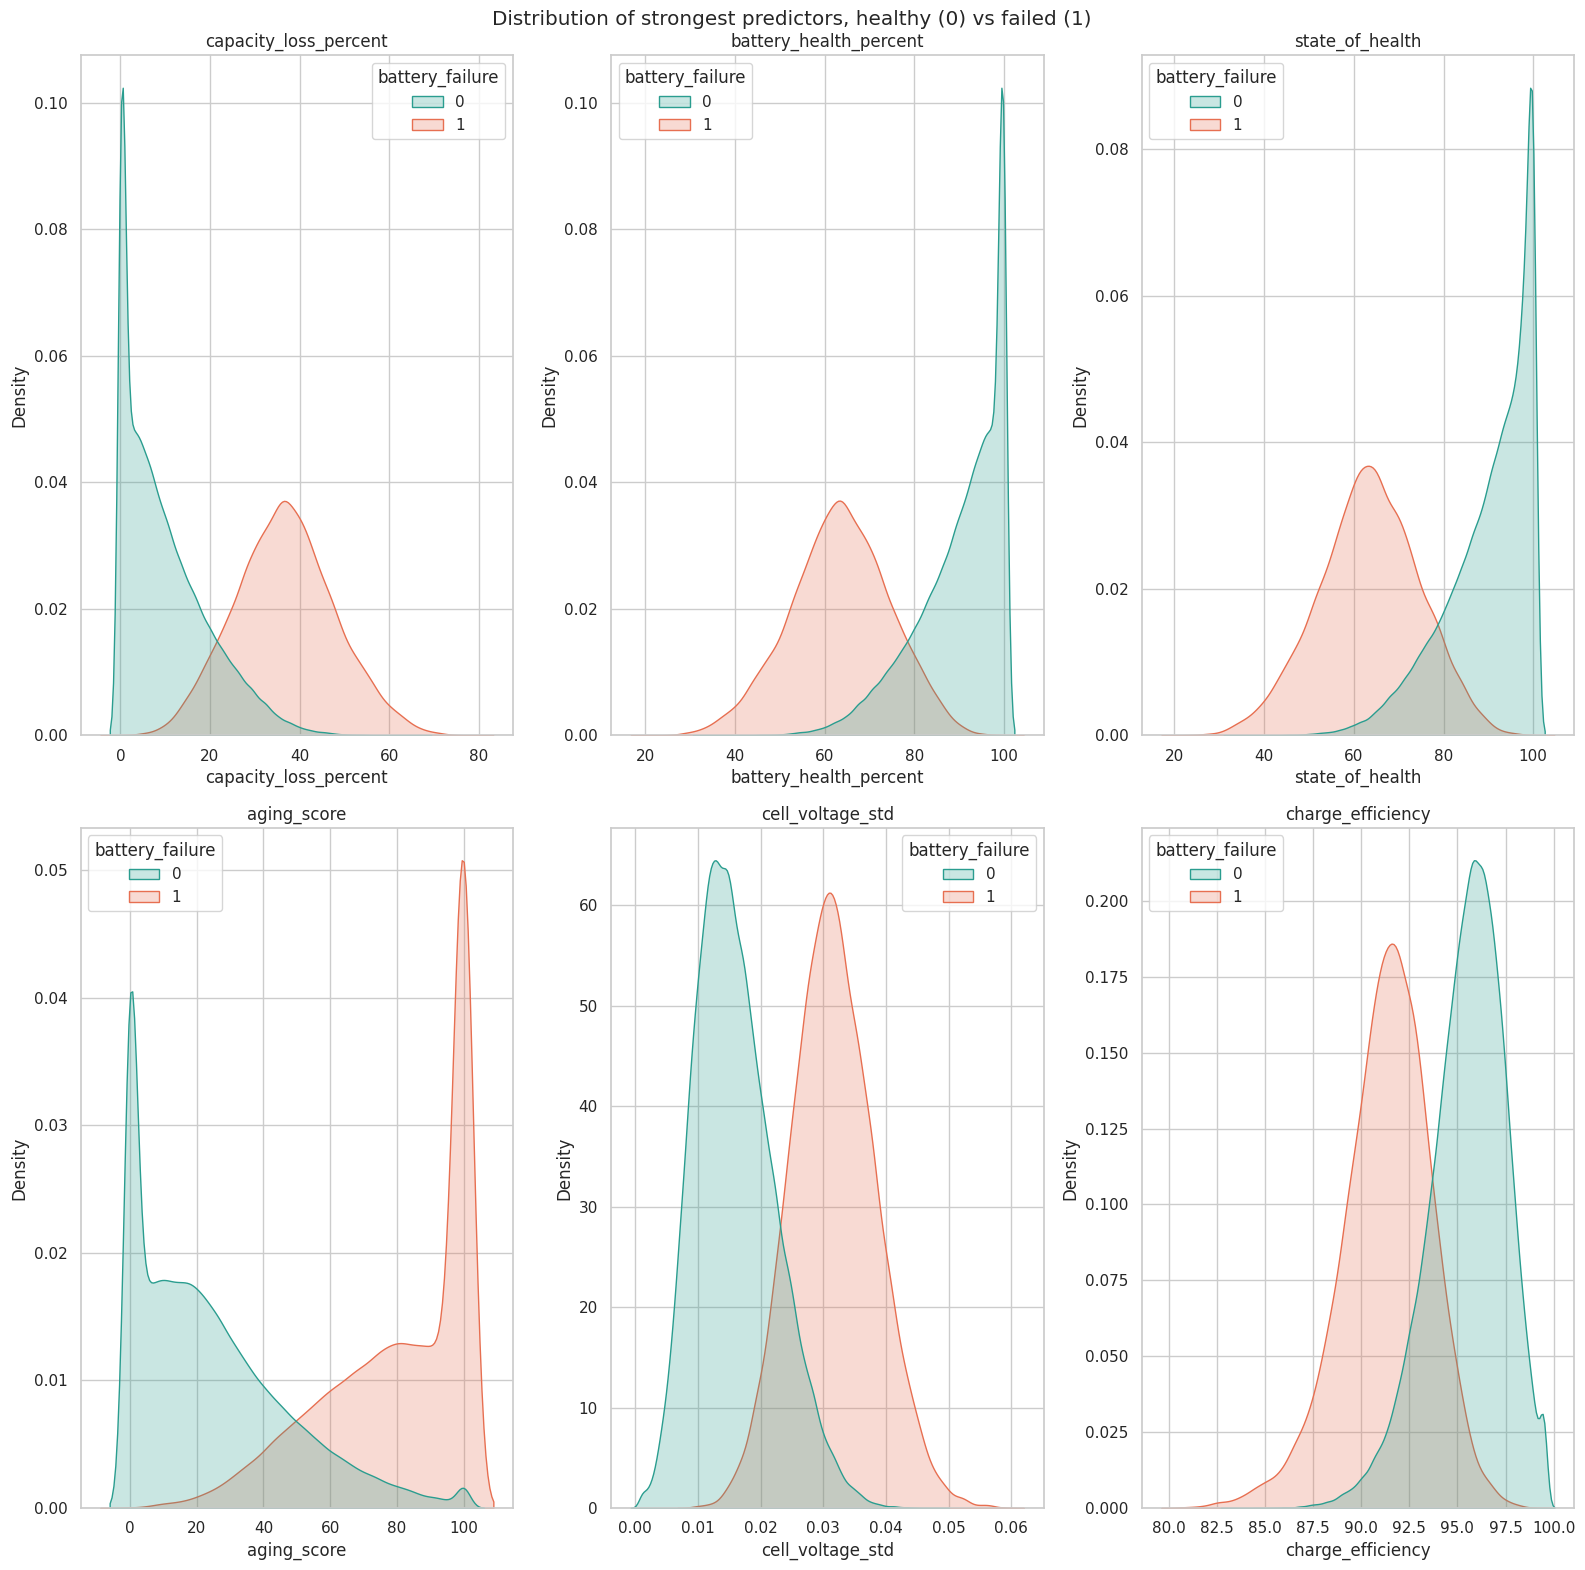

In [ ]:
# distributions of top drivers split by class

top5 = corr_t.head(6).index.tolist()

# Set up the plotting grid
fig, axes = plt.subplots(2, 3, figsize=(16, 16))

# Loop through the axes and features simultaneously
# Plot the density distribution (KDE)
for a, c in zip(axes.ravel(), top5):
    sns.kdeplot(data=df, x=c, hue=TARGET, common_norm=False, fill=True, ax=a,
                palette=['#2a9d8f', '#e76f51'], warn_singular=False)
    a.set_title(c)

plt.suptitle('Distribution of strongest predictors, healthy (0) vs failed (1)')
plt.tight_layout()
plt.savefig(f'{OUT}/fig3_distributions.png', dpi=110)
plt.show()

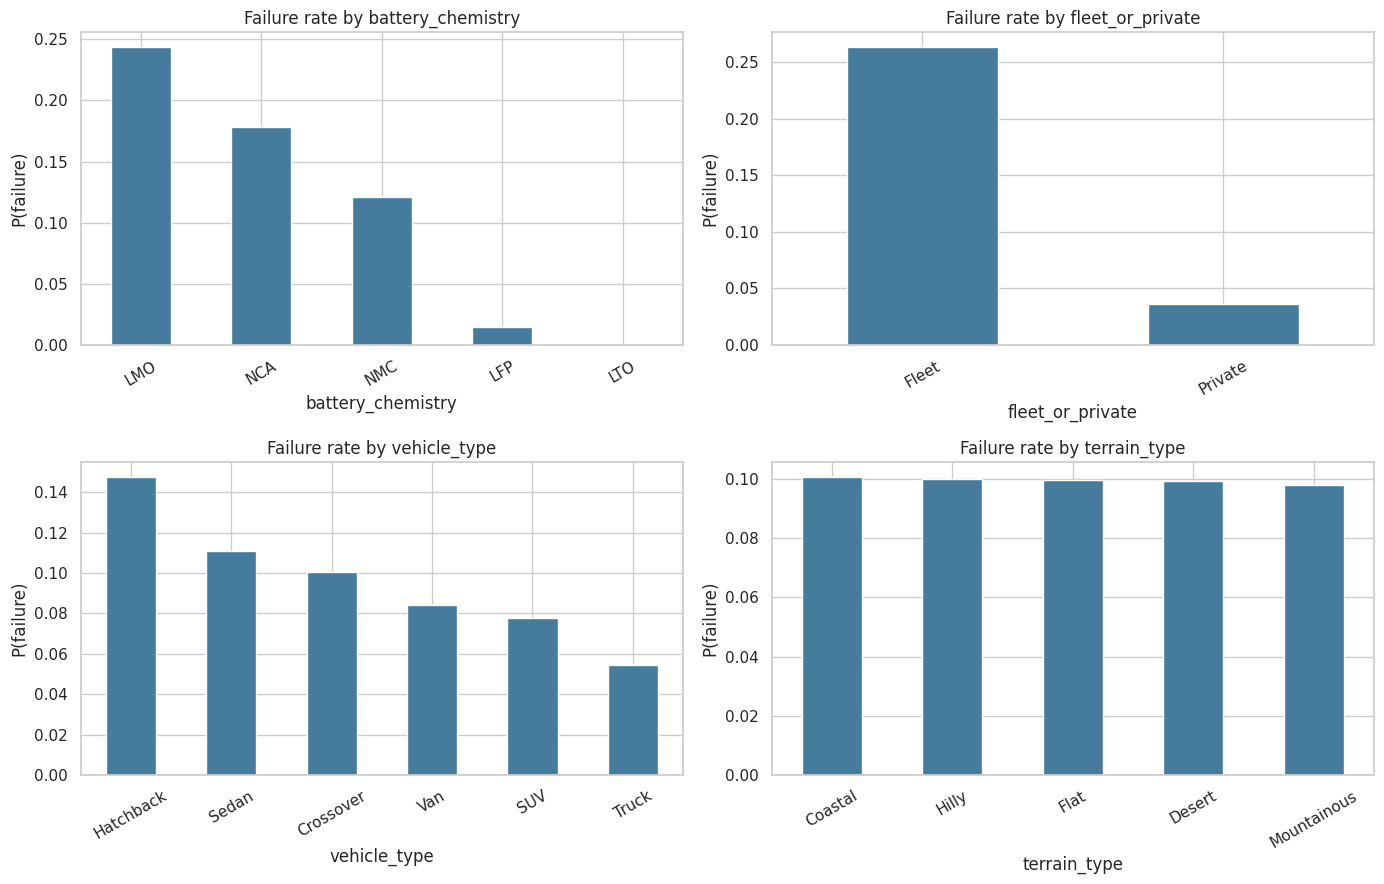

In [ ]:
# categorical failure rates

# Select the categorical features to visualize
cat_eda = ['battery_chemistry', 'fleet_or_private', 'vehicle_type', 'terrain_type']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
cat_rates = {}

for a, c in zip(axes.ravel(), cat_eda):
    r = df.groupby(c)[TARGET].mean().sort_values(ascending=False)
    cat_rates[c] = r.round(4).to_dict()
    r.plot(kind='bar', ax=a, color='#457b9d'); a.set_title(f'Failure rate by {c}')
    a.set_ylabel('P(failure)'); a.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{OUT}/fig4_categorical_rates.png', dpi=110)
plt.show()
eda['categorical_failure_rates'] = cat_rates

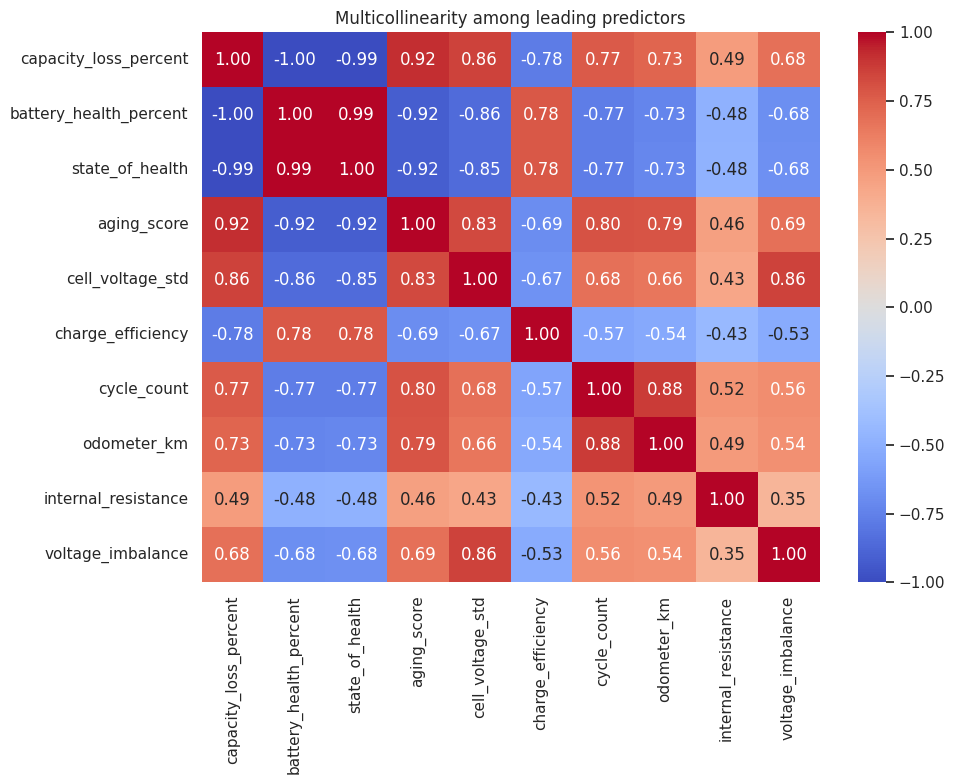

[  42.9s] EDA figures written


In [ ]:
# Correlation heatmap among top features
hm = df[top5 + ['cycle_count', 'odometer_km', 'internal_resistance', 'voltage_imbalance']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(hm, annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Multicollinearity among leading predictors')
plt.tight_layout()
plt.savefig(f'{OUT}/fig5_corr_heatmap.png', dpi=110)
plt.show()
log("EDA figures written")

# Feature Engineering

In [ ]:
ID_COLS = ['vehicle_id', 'battery_serial']
d = df.drop(columns=ID_COLS).copy()

# Domain features

# We add a tiny number (epsilon) to all denominators. This prevents the script from crashing
# with a ZeroDivisionError if a vehicle happens to have 0 cycle_counts or 0 age.

eps = 1e-6
d['soh_per_cycle']        = d['state_of_health'] / (d['cycle_count'] + eps)
d['km_per_cycle']         = d['odometer_km'] / (d['cycle_count'] + eps)
d['degradation_rate']     = d['capacity_loss_percent'] / (d['vehicle_age_years'] + eps)
d['thermal_spread']       = d['cell_temperature_max'] - d['cell_temperature_avg']
d['resistance_x_cycles']  = d['internal_resistance'] * d['cycle_count']
d['efficiency_gap']       = d['charge_efficiency'] - d['discharge_efficiency']
d['fast_charge_burden']   = d['fast_charge_ratio'] * d['charging_cycles_last_month']
d['stress_per_age']       = d['battery_stress_index'] / (d['vehicle_age_years'] + eps)
d['imbalance_ratio_feat'] = d['cell_voltage_std'] / (d['cell_voltage_avg'] + eps)

# Keep a list of these new features so we can track their importance later
NEW_FEATURES = ['soh_per_cycle', 'km_per_cycle', 'degradation_rate', 'thermal_spread',
                'resistance_x_cycles', 'efficiency_gap', 'fast_charge_burden',
                'stress_per_age', 'imbalance_ratio_feat']
d = d.replace([np.inf, -np.inf], np.nan)

# Separate Features (X) and Target (y)
X = d.drop(columns=[TARGET])
y = d[TARGET].astype(int)

# list of all numeric columns (which now includes our 9 new engineered features)
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# the (string/object columns) to be processed as categoricals.
cat_cols = [c for c in X.columns if c not in num_cols]

# Log the final counts to monitor the data shape before passing it to the models.
log(f"Features: {len(num_cols)} numeric, {len(cat_cols)} categorical, {len(NEW_FEATURES)} engineered")

[  44.0s] Features: 68 numeric, 8 categorical, 9 engineered


# Train and Test Split

In [ ]:
# First Split: Separate out the Hold-Out Test Set
# We take 20% of the entire dataset to lock away for final evaluation.

X_temp, X_te, y_temp, y_te = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Second Split: Separate Train and Validation Sets
# We split the remaining 80% (X_temp) into Training and Validation sets.
# Setting test_size=0.25 here takes 25% of the 80% block (which equals exactly 20% of the total original data).
# This gives us a final distribution of 60% Train, 20% Val, 20% Test.

X_tr, X_val, y_tr, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# log the shapes to verify the row counts (e.g., 120k Train, 40k Val, 40k Test).
log(f"Train {X_tr.shape} | Val {X_val.shape} | Test {X_te.shape}")

# We check the mean of the targets to prove stratify worked and the failure rate is identical across all sets.
log(f"Train pos {y_tr.mean():.4f} | Val pos {y_val.mean():.4f} | Test pos {y_te.mean():.4f}")

[  45.0s] Train (120000, 76) | Val (40000, 76) | Test (40000, 76)
[  45.0s] Train pos 0.0996 | Val pos 0.0996 | Test pos 0.0996


# Data Pre-processing

In [ ]:

# Pipeline for Linear Models (Numeric Features)
# Fills missing numeric values with the median of that column.
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler', StandardScaler())])

# Pipeline for Categorical Features
# Fills missing string values with the most common category (mode).
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                     ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preproc = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

# Tree models don't need scaling
num_pipe_tree = Pipeline([('imputer', SimpleImputer(strategy='median'))])

# Master Transformer (Linear Models)
preproc_tree = ColumnTransformer([('num', num_pipe_tree, num_cols), ('cat', cat_pipe, cat_cols)])

# Calculate Scale Pos Weight for highly imbalanced data
spw = float((y_tr == 0).sum() / (y_tr == 1).sum())
log(f"scale_pos_weight = {spw:.3f}")


[  45.1s] scale_pos_weight = 9.039


# Models

In [ ]:
models = {
    # Logistic Regression
    'Logistic Regression': Pipeline([('prep', preproc),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))]),

    # Random Forest
    'Random Forest': Pipeline([('prep', preproc_tree),
        ('clf', RandomForestClassifier(n_estimators=150, max_depth=14, min_samples_leaf=10,
                                       class_weight='balanced_subsample', n_jobs=-1,
                                       random_state=RANDOM_STATE))]),

    # XGBoost
    'XGBoost': Pipeline([('prep', preproc_tree),
        ('clf', XGBClassifier(n_estimators=350, max_depth=6, learning_rate=0.08,
                              subsample=0.9, colsample_bytree=0.8, scale_pos_weight=spw,
                              eval_metric='aucpr', tree_method='hist', n_jobs=-1,
                              random_state=RANDOM_STATE))]),

    # LightGBM
    'LightGBM': Pipeline([('prep', preproc_tree),
        ('clf', LGBMClassifier(n_estimators=400, learning_rate=0.06, num_leaves=48,
                               scale_pos_weight=spw, n_jobs=-1, verbose=-1,
                               random_state=RANDOM_STATE))]),
}

# Set up Cross-Validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

# Evaluate Each Model
for name, pipe in models.items():
    s = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='average_precision', n_jobs=1)
    cv_results[name] = {'pr_auc_mean': float(s.mean()), 'pr_auc_std': float(s.std())}
    log(f"CV {name}: PR-AUC {s.mean():.4f} +/- {s.std():.4f}")

# Save the final cross-validation scores to our main results dictionary
RESULTS['cv'] = cv_results

[  64.1s] CV Logistic Regression: PR-AUC 0.9224 +/- 0.0014
[ 265.1s] CV Random Forest: PR-AUC 0.8742 +/- 0.0018
[ 361.1s] CV XGBoost: PR-AUC 0.9171 +/- 0.0017
[ 433.5s] CV LightGBM: PR-AUC 0.9169 +/- 0.0017


# Fit and Test Evaluation

In [ ]:
# Define a robust evaluation function

def evaluate(name, pipe, thr=0.5):
    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:, 1]
    pred = (proba >= thr).astype(int)
    m = {'accuracy': accuracy_score(y_te, pred), 'precision': precision_score(y_te, pred, zero_division=0),
         'recall': recall_score(y_te, pred), 'f1': f1_score(y_te, pred),
         'roc_auc': roc_auc_score(y_te, proba), 'pr_auc': average_precision_score(y_te, proba)}
    return pipe, proba, {k: round(float(v), 4) for k, v in m.items()}

test_metrics, probas, fitted = {}, {}, {}

# Evaluate all models
for name, pipe in models.items():
    fitted[name], probas[name], test_metrics[name] = evaluate(name, pipe)
    log(f"TEST {name}: {test_metrics[name]}")

# Save the raw metrics to our master RESULTS dictionary for later JSON export
RESULTS['test_default_threshold'] = test_metrics

# identify the best model
best_name = max(test_metrics, key=lambda k: test_metrics[k]['pr_auc'])
log(f"Best baseline model: {best_name}")

[ 441.3s] TEST Logistic Regression: {'accuracy': 0.9411, 'precision': 0.6357, 'recall': 0.9566, 'f1': 0.7638, 'roc_auc': 0.9892, 'pr_auc': 0.9213}
[ 544.5s] TEST Random Forest: {'accuracy': 0.9443, 'precision': 0.6614, 'recall': 0.9026, 'f1': 0.7634, 'roc_auc': 0.9833, 'pr_auc': 0.8782}
[ 578.6s] TEST XGBoost: {'accuracy': 0.9566, 'precision': 0.724, 'recall': 0.9114, 'f1': 0.807, 'roc_auc': 0.9885, 'pr_auc': 0.9176}
[ 613.6s] TEST LightGBM: {'accuracy': 0.9561, 'precision': 0.72, 'recall': 0.9157, 'f1': 0.8061, 'roc_auc': 0.9886, 'pr_auc': 0.9164}
[ 613.6s] Best baseline model: Logistic Regression


# Hyperparameter Tuning

In [ ]:
# Define the Hyperparameter Search Space

param_dist = {
    'clf__n_estimators': [300, 450, 600],
    'clf__max_depth': [4, 6, 8, 10],
    'clf__learning_rate': [0.03, 0.05, 0.08, 0.12],
    'clf__subsample': [0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
    'clf__min_child_weight': [1, 3, 5, 10],
    'clf__gamma': [0, 0.1, 0.3],
    'clf__reg_lambda': [1, 3, 10],
}

# Setup the Tuning Pipeline
tune_pipe = Pipeline([('prep', preproc_tree),
    ('clf', XGBClassifier(scale_pos_weight=spw, eval_metric='aucpr', tree_method='hist',
                          n_jobs=-1, random_state=RANDOM_STATE))])

# Search on a stratified 50k subsample (single-core budget), then refit on full train
X_s, _, y_s, _ = train_test_split(X_tr, y_tr, train_size=50000, stratify=y_tr, random_state=RANDOM_STATE)

# Execute the Randomized Search
search = RandomizedSearchCV(tune_pipe, param_dist, n_iter=8, scoring='average_precision',
                            cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                            n_jobs=1, random_state=RANDOM_STATE, verbose=0, refit=False)

# Run the search on the 50k subsample
search.fit(X_s, y_s)
log(f"Best params: {search.best_params_}")
log(f"Best CV PR-AUC: {search.best_score_:.4f}")

# JSON Serialization Safety Net
RESULTS['tuning'] = {'best_params': {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                                     for k, v in search.best_params_.items()},
                     'best_cv_pr_auc': float(search.best_score_)}

# Apply the Best Parameters
final_model = tune_pipe.set_params(**search.best_params_)

# Refit on the Full Training Set
final_model.fit(X_tr, y_tr)

# Score against the Hold-Out Test Set
final_proba = final_model.predict_proba(X_te)[:, 1]
final_pred = (final_proba >= 0.5).astype(int)

# Store and Log Results
RESULTS['final_default_threshold'] = {
    'accuracy': round(float(accuracy_score(y_te, final_pred)), 4),
    'precision': round(float(precision_score(y_te, final_pred)), 4),
    'recall': round(float(recall_score(y_te, final_pred)), 4),
    'f1': round(float(f1_score(y_te, final_pred)), 4),
    'roc_auc': round(float(roc_auc_score(y_te, final_proba)), 4),
    'pr_auc': round(float(average_precision_score(y_te, final_proba)), 4)}
log(f"FINAL @0.5: {RESULTS['final_default_threshold']}")

[1181.0s] Best params: {'clf__subsample': 0.7, 'clf__reg_lambda': 10, 'clf__n_estimators': 600, 'clf__min_child_weight': 10, 'clf__max_depth': 6, 'clf__learning_rate': 0.05, 'clf__gamma': 0, 'clf__colsample_bytree': 0.6}
[1181.0s] Best CV PR-AUC: 0.9144
[1234.6s] FINAL @0.5: {'accuracy': 0.9553, 'precision': 0.7127, 'recall': 0.9239, 'f1': 0.8047, 'roc_auc': 0.989, 'pr_auc': 0.9196}


# Threshold Optimization

In [ ]:
# Calculate Precision and Recall across all possible thresholds
prec, rec, thr = precision_recall_curve(y_te, final_proba)

# Vectorized F1 Score Calculation
f1s = 2 * prec * rec / (prec + rec + 1e-12)

# Find the Optimal F1 Threshold
best_i = int(np.nanargmax(f1s[:-1]))
best_thr = float(thr[best_i])

# Apply the Tuned Threshold
tuned_pred = (final_proba >= best_thr).astype(int)

# Store the Optimized Results
RESULTS['optimal_threshold'] = round(best_thr, 4)
RESULTS['final_tuned_threshold'] = {
    'threshold': round(best_thr, 4),
    'accuracy': round(float(accuracy_score(y_te, tuned_pred)), 4),
    'precision': round(float(precision_score(y_te, tuned_pred)), 4),
    'recall': round(float(recall_score(y_te, tuned_pred)), 4),
    'f1': round(float(f1_score(y_te, tuned_pred)), 4)}
log(f"FINAL @{best_thr:.3f}: {RESULTS['final_tuned_threshold']}")

# Recall-90 operating point (maintenance scheduling view)
idx90 = np.where(rec[:-1] >= 0.90)[0]
if len(idx90):
    j = idx90[np.argmax(prec[:-1][idx90])]
    RESULTS['recall90_operating_point'] = {'threshold': round(float(thr[j]), 4),
                                           'precision': round(float(prec[j]), 4),
                                           'recall': round(float(rec[j]), 4)}

# Standard ML Artifacts
cm = confusion_matrix(y_te, tuned_pred)

RESULTS['confusion_matrix_tuned'] = cm.tolist()
RESULTS['classification_report'] = classification_report(y_te, tuned_pred, target_names=['healthy', 'failure'], output_dict=True)

[1234.6s] FINAL @0.775: {'threshold': 0.7749, 'accuracy': 0.9653, 'precision': 0.8146, 'recall': 0.8439, 'f1': 0.829}


# Evaluation Plots

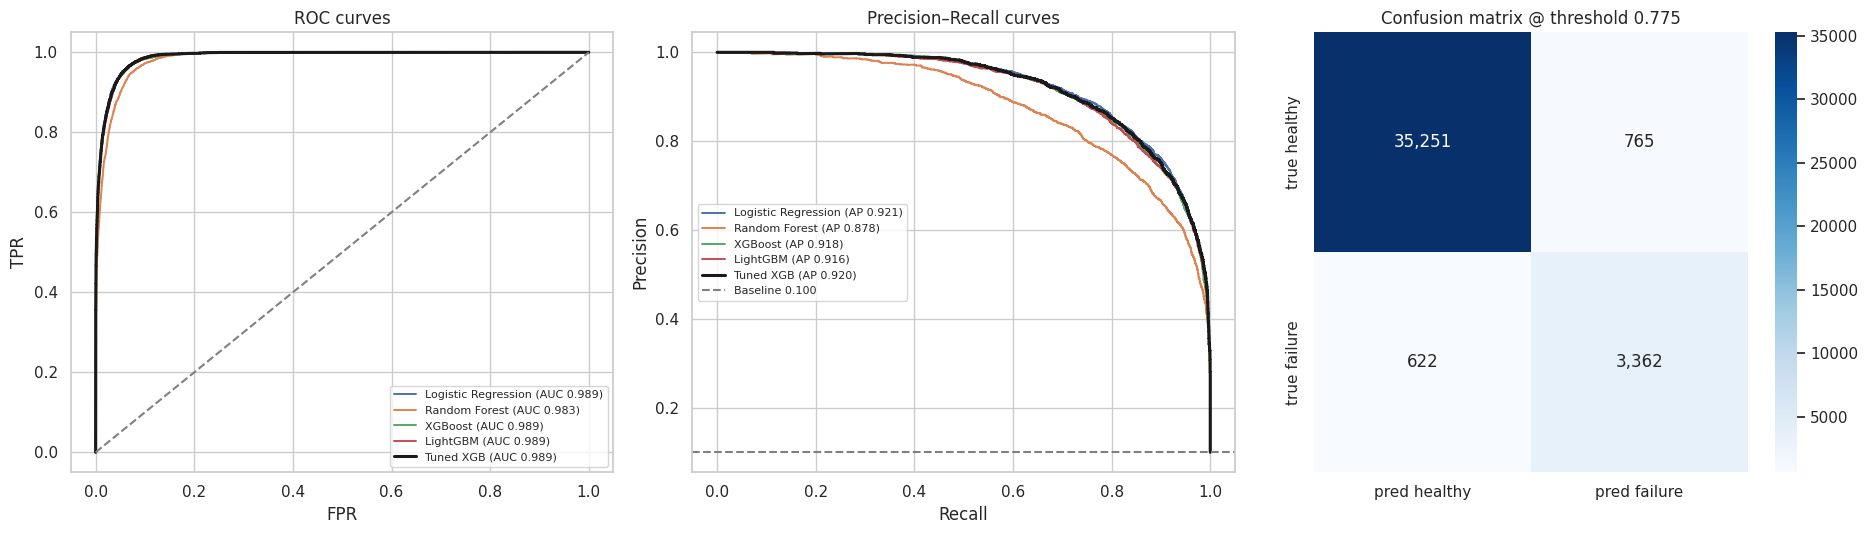

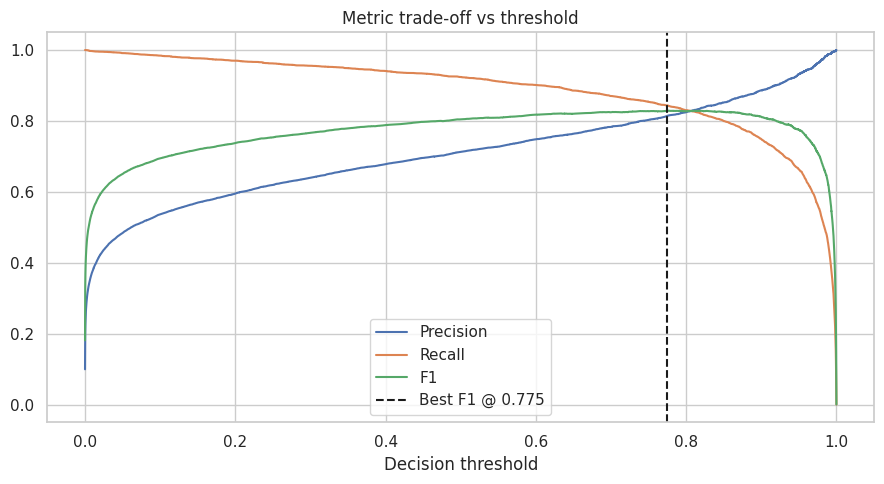

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(19, 5.5))

# Loop through all our baseline models and plot their standard ROC curves
for name in models:
    fpr, tpr, _ = roc_curve(y_te, probas[name])
    ax[0].plot(fpr, tpr, lw=1.4, label=f"{name} (AUC {test_metrics[name]['roc_auc']:.3f})")

# Plot the final Tuned XGBoost model on top in a bold black line
fpr, tpr, _ = roc_curve(y_te, final_proba)
ax[0].plot(fpr, tpr, 'k-', lw=2.2, label=f"Tuned XGB (AUC {RESULTS['final_default_threshold']['roc_auc']:.3f})")

# Add the 50/50 random guess diagonal line and format the axes
ax[0].plot([0, 1], [0, 1], '--', color='grey'); ax[0].set_xlabel('FPR')
ax[0].set_ylabel('TPR')
ax[0].set_title('ROC curves')
ax[0].legend(fontsize=8)

# Loop through baselines and plot PR curves
for name in models:
    p, r, _ = precision_recall_curve(y_te, probas[name])
    ax[1].plot(r, p, lw=1.4, label=f"{name} (AP {test_metrics[name]['pr_auc']:.3f})")

# Plot the Tuned XGBoost PR curve in bold black
ax[1].plot(rec, prec, 'k-', lw=2.2, label=f"Tuned XGB (AP {RESULTS['final_default_threshold']['pr_auc']:.3f})")

# The baseline for a PR curve is NOT 50/50. It is the percentage of positive classes (~10%).
ax[1].axhline(y_te.mean(), ls='--', color='grey', label=f'Baseline {y_te.mean():.3f}')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision–Recall curves')
ax[1].legend(fontsize=8)

# create a heatmap of our confusion matrix based on the TUNED threshold.
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax[2],
            xticklabels=['pred healthy', 'pred failure'], yticklabels=['true healthy', 'true failure'])
ax[2].set_title(f'Confusion matrix @ threshold {best_thr:.3f}')

# Finalize layout, save, and display
plt.tight_layout()
plt.savefig(f'{OUT}/fig6_model_evaluation.png', dpi=110)
plt.show()

# Threshold sweep
plt.figure(figsize=(9, 5))

# Plot Precision, Recall, and F1 across all possible thresholds
plt.plot(thr, prec[:-1], label='Precision')
plt.plot(thr, rec[:-1], label='Recall')
plt.plot(thr, f1s[:-1], label='F1')

# Draw a vertical dashed line exactly where our optimal F1 threshold sits
plt.axvline(best_thr, ls='--', color='k', label=f'Best F1 @ {best_thr:.3f}')
plt.xlabel('Decision threshold')
plt.legend()
plt.title('Metric trade-off vs threshold')
plt.tight_layout()
plt.savefig(f'{OUT}/fig7_threshold_sweep.png', dpi=110)
plt.show()

# Feature Importance

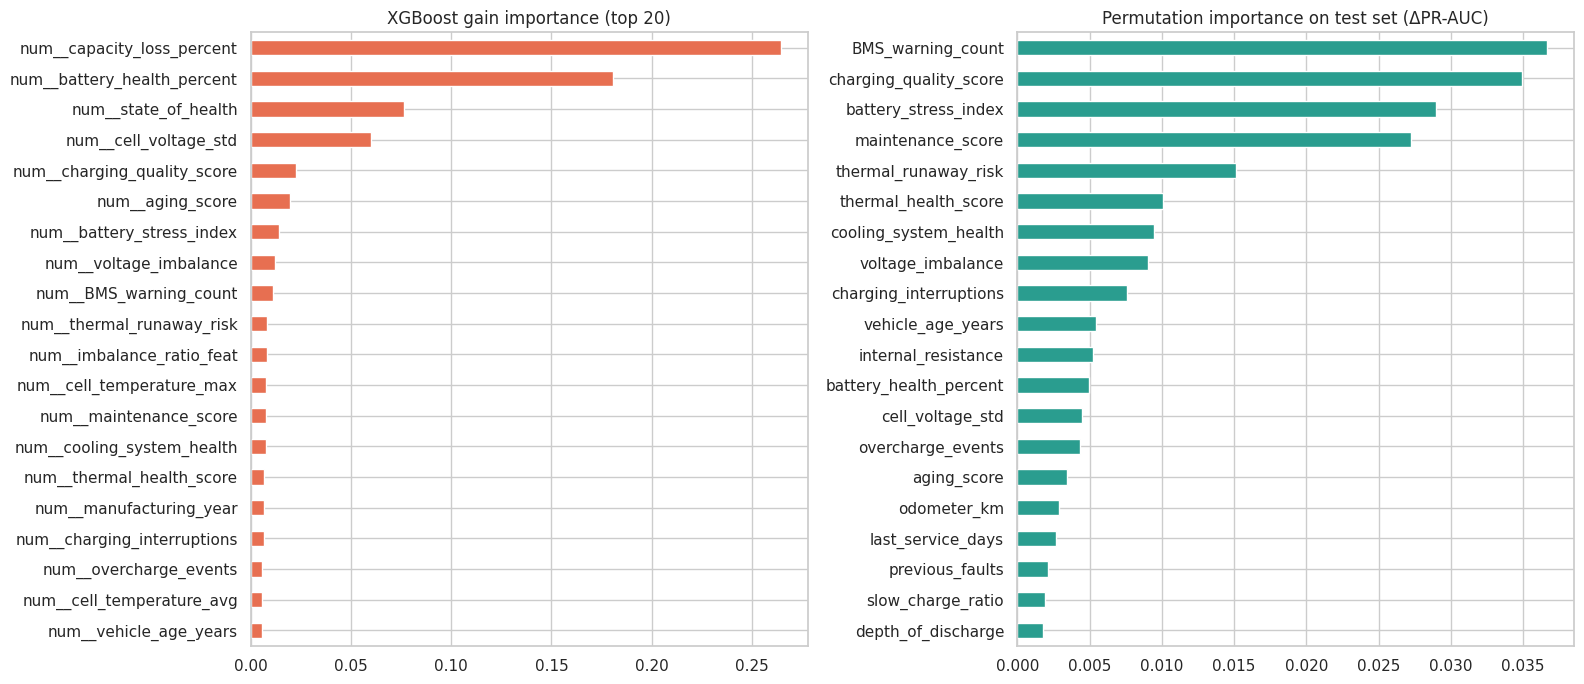

In [ ]:
# XGBoost Native Gain Importance

# Extract feature names from the preprocessing pipeline
feat_names = final_model.named_steps['prep'].get_feature_names_out()

# Extract XGBoost 'Gain'
gains = final_model.named_steps['clf'].feature_importances_

imp = pd.Series(gains, index=feat_names).sort_values(ascending=False)

# Save the top 20 native features to our results dictionary.
RESULTS['top_importances_gain'] = imp.head(20).round(5).to_dict()

# Subsample the Test Set for Speed
sub = np.random.RandomState(RANDOM_STATE).choice(len(X_te), 5000, replace=False)

# Calculate Permutation Importance
perm = permutation_importance(final_model, X_te.iloc[sub], y_te.iloc[sub], n_repeats=3,
                              scoring='average_precision', random_state=RANDOM_STATE, n_jobs=1)

# Note: Permutation importance uses the ORIGINAL columns from X_te, not the transformed ones.
perm_s = pd.Series(perm.importances_mean, index=X_te.columns).sort_values(ascending=False)
RESULTS['top_importances_permutation'] = perm_s.head(20).round(5).to_dict()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot Gain (Native XGBoost math)
imp.head(20).iloc[::-1].plot(kind='barh', ax=ax[0], color='#e76f51')
ax[0].set_title('XGBoost gain importance (top 20)')

# Plot Permutation (Real-world impact on PR-AUC)
perm_s.head(20).iloc[::-1].plot(kind='barh', ax=ax[1], color='#2a9d8f')
ax[1].set_title('Permutation importance on test set (ΔPR-AUC)')

plt.tight_layout()
plt.savefig(f'{OUT}/fig8_feature_importance.png', dpi=110)
plt.show()

# Rank the custom features
eng_rank = {f: int(list(perm_s.index).index(f)) + 1 for f in NEW_FEATURES if f in perm_s.index}
RESULTS['engineered_feature_ranks'] = eng_rank

# Business Impact

In [ ]:
# Define Business Assumptions (Financials)
# A catastrophic, unplanned battery failure in the field costs $8,000 (towing, full replacement, brand damage).
# A preemptive diagnostic check and minor maintenance in the shop costs $250.

COST_FAILURE, COST_INSPECT = 8000, 250   # USD, illustrative

# Unpack the Confusion Matrix
tn, fp, fn, tp = cm.ravel()

# Calculate Model Costs
cost_model = tp * COST_INSPECT + fp * COST_INSPECT + fn * COST_FAILURE

# Calculate Baseline Costs
cost_none = (tp + fn) * COST_FAILURE

# Store the Final Financial Report
RESULTS['business_case'] = {
    'assumed_cost_per_unplanned_failure_usd': COST_FAILURE,
    'assumed_cost_per_inspection_usd': COST_INSPECT,
    'cost_no_model_usd': int(cost_none),
    'cost_with_model_usd': int(cost_model),
    'savings_usd': int(cost_none - cost_model),
    'savings_pct': round(float((cost_none - cost_model) / cost_none * 100), 2),
    'failures_caught': int(tp), 'failures_missed': int(fn), 'false_alarms': int(fp)}

# Export and Metadata

In [ ]:
# Package the Final Production Artifact
joblib.dump({'model': final_model, 'threshold': best_thr,
             'num_cols': num_cols, 'cat_cols': cat_cols,
             'engineered': NEW_FEATURES}, f'{OUT}/ev_battery_failure_model.joblib')

# Finalize the Master Results Dictionary
RESULTS['eda'] = eda
RESULTS['runtime_sec'] = round(time.time() - t0, 1)

# Save the JSON Report
with open(f'{OUT}/results.json', 'w') as f:
    json.dump(RESULTS, f, indent=2, default=str)

# Final Logging
log("DONE — model + results saved")

# Print a Clean Executive Summary to the Console
print(json.dumps({k: v for k, v in RESULTS.items() if k not in ('eda', 'classification_report')}, indent=2, default=str))

[1269.0s] DONE — model + results saved
{
  "cv": {
    "Logistic Regression": {
      "pr_auc_mean": 0.9223876702401993,
      "pr_auc_std": 0.0013952040693543987
    },
    "Random Forest": {
      "pr_auc_mean": 0.8741907811769646,
      "pr_auc_std": 0.0017582962564938512
    },
    "XGBoost": {
      "pr_auc_mean": 0.9171114564857219,
      "pr_auc_std": 0.0017040279059549258
    },
    "LightGBM": {
      "pr_auc_mean": 0.9168833270135388,
      "pr_auc_std": 0.0016940045429327689
    }
  },
  "test_default_threshold": {
    "Logistic Regression": {
      "accuracy": 0.9411,
      "precision": 0.6357,
      "recall": 0.9566,
      "f1": 0.7638,
      "roc_auc": 0.9892,
      "pr_auc": 0.9213
    },
    "Random Forest": {
      "accuracy": 0.9443,
      "precision": 0.6614,
      "recall": 0.9026,
      "f1": 0.7634,
      "roc_auc": 0.9833,
      "pr_auc": 0.8782
    },
    "XGBoost": {
      "accuracy": 0.9566,
      "precision": 0.724,
      "recall": 0.9114,
      "f1": 0.807,
